# Phase 3 — Model Training (wav2vec2 + ResNet50)

**Run AFTER Phase 1&2 v2 is complete.**
Features cached at `MyDrive/crema_msa_v2/features/`

Architecture:
- Audio: wav2vec2 features (768-d) — strong signal confirmed (dist=0.17)
- Video: ResNet50 features (512-d) — supporting signal (dist=0.03)
- Fusion: CoAttention + Transformer
- Output: 6 emotions → clustered to 3 sentiments at prediction time

## Cell 1 — Imports and setup

In [1]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report,
    roc_curve, auc, roc_auc_score, cohen_kappa_score, matthews_corrcoef
)
from sklearn.preprocessing import label_binarize

warnings.filterwarnings('ignore')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device  : {DEVICE}')
assert str(DEVICE) == 'cuda', 'GPU not available — go to Runtime > Change runtime type > T4 GPU'

EMOTION_NAMES   = {0:'ANG', 1:'DIS', 2:'FEA', 3:'SAD', 4:'NEU', 5:'HAP'}
EMOTION_TO_SENT = {0:0, 1:0, 2:0, 3:0, 4:1, 5:2}
SENTIMENT_NAMES = {0:'Negative', 1:'Neutral', 2:'Positive'}
SAVE_DIR        = '/content/drive/MyDrive/crema_msa_v2'
print('Setup OK')

Device  : cuda
Setup OK


## Cell 2 — Mount Drive and load features

In [2]:
from google.colab import drive
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')
else:
    print('Drive already mounted.')

CACHE_DIR = f'{SAVE_DIR}/features'

def load_split(name):
    path = f'{CACHE_DIR}/{name}.npz'
    assert os.path.exists(path), f'Not found: {path} — run Phase 1&2 v2 first'
    d = np.load(path)
    return d['audio'], d['video'], d['labels']

train_audio, train_video, train_labels = load_split('train')
val_audio,   val_video,   val_labels   = load_split('val')
test_audio,  test_video,  test_labels  = load_split('test')

print('Features loaded:')
print(f'  Train : audio={train_audio.shape}  video={train_video.shape}  labels={train_labels.shape}')
print(f'  Val   : audio={val_audio.shape}    video={val_video.shape}    labels={val_labels.shape}')
print(f'  Test  : audio={test_audio.shape}   video={test_video.shape}   labels={test_labels.shape}')
print()
print('Train label counts:')
for i in range(6):
    print(f'  {EMOTION_NAMES[i]} : {(train_labels==i).sum()}')

Mounted at /content/drive
Features loaded:
  Train : audio=(5146, 768)  video=(5146, 512)  labels=(5146,)
  Val   : audio=(1148, 768)    video=(1148, 512)    labels=(1148,)
  Test  : audio=(1147, 768)   video=(1147, 512)   labels=(1147,)

Train label counts:
  ANG : 879
  DIS : 879
  FEA : 879
  SAD : 878
  NEU : 752
  HAP : 879


## Cell 3 — Dataset and DataLoader

In [3]:
class MultimodalDataset(Dataset):
    def __init__(self, audio, video, labels, augment=False):
        self.audio   = torch.tensor(audio,  dtype=torch.float32)
        self.video   = torch.tensor(video,  dtype=torch.float32)
        self.labels  = torch.tensor(labels, dtype=torch.long)
        self.augment = augment

    def __len__(self): return len(self.labels)

    def __getitem__(self, idx):
        a = self.audio[idx]
        v = self.video[idx]
        l = self.labels[idx]
        if self.augment and torch.rand(1).item() > 0.5:
            # Small noise augmentation — keeps features on unit sphere
            a = F.normalize(a + torch.randn_like(a) * 0.01, dim=0)
            v = F.normalize(v + torch.randn_like(v) * 0.01, dim=0)
        return a, v, l


def make_loader(audio, video, labels, batch_size, augment=False, balance=False):
    ds      = MultimodalDataset(audio, video, labels, augment=augment)
    sampler = None
    shuffle = augment
    if balance:
        counts        = np.bincount(labels)
        sample_w      = (1.0 / counts)[labels]
        sampler       = WeightedRandomSampler(
            torch.tensor(sample_w, dtype=torch.float32),
            num_samples=len(sample_w), replacement=True
        )
        shuffle = False
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      sampler=sampler, num_workers=2, pin_memory=True)


BATCH        = 32
train_loader = make_loader(train_audio, train_video, train_labels, BATCH, augment=True,  balance=True)
val_loader   = make_loader(val_audio,   val_video,   val_labels,   BATCH, augment=False, balance=False)
test_loader  = make_loader(test_audio,  test_video,  test_labels,  BATCH, augment=False, balance=False)

print(f'Train batches: {len(train_loader)}  Val: {len(val_loader)}  Test: {len(test_loader)}')

# Quick sampler balance check
sample_labels = []
for a, v, l in train_loader:
    sample_labels.extend(l.numpy())
counts = np.bincount(sample_labels)
print('Sampler balance (one epoch):')
for i, c in enumerate(counts):
    print(f'  {EMOTION_NAMES[i]} : {c}')
print('Should be roughly equal — confirms sampler is working.')

Train batches: 161  Val: 36  Test: 36
Sampler balance (one epoch):
  ANG : 852
  DIS : 907
  FEA : 828
  SAD : 883
  NEU : 821
  HAP : 855
Should be roughly equal — confirms sampler is working.


## Cell 4 — Model definition

**Two-modality CoAttention:**
- Audio (768-d) attends to Video (512-d): does the face match the voice?
- Video (512-d) attends to Audio (768-d): does the voice match the face?
- Fused → Transformer → 6-class classifier

**Key design decisions:**
- `norm_first=True` in Transformer: Pre-LayerNorm is more stable than Post-LN
- `label_smoothing=0.1` in loss: prevents overconfident predictions
- `hidden_dim=256`: big enough to capture cross-modal patterns, small enough to train fast
- L2 normalise after projection: keeps attention scores balanced between modalities

In [4]:
class TwoModalCoAttention(nn.Module):
    """
    Cross-attention between two modalities.
    Audio attends to Video, Video attends to Audio.
    Returns fused vector of size hidden_dim.
    """
    def __init__(self, hidden_dim, num_heads=4, dropout=0.2):
        super().__init__()
        # Audio queries Video
        self.attn_av = nn.MultiheadAttention(
            hidden_dim, num_heads, dropout=dropout, batch_first=True)
        # Video queries Audio
        self.attn_va = nn.MultiheadAttention(
            hidden_dim, num_heads, dropout=dropout, batch_first=True)

        # Learnable gate: how much to trust audio vs video
        self.gate = nn.Parameter(torch.tensor(0.5))

        self.fusion = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

    def forward(self, a, v):
        # a: (B, hidden_dim)  v: (B, hidden_dim)
        a_seq = a.unsqueeze(1)   # (B, 1, hidden_dim)
        v_seq = v.unsqueeze(1)   # (B, 1, hidden_dim)

        av, _ = self.attn_av(a_seq, v_seq, v_seq)   # audio queries video
        va, _ = self.attn_va(v_seq, a_seq, a_seq)   # video queries audio

        av = av.squeeze(1)   # (B, hidden_dim)
        va = va.squeeze(1)

        g = torch.sigmoid(self.gate)
        combined = torch.cat([g * av, (1-g) * va], dim=-1)   # (B, hidden_dim*2)
        return self.fusion(combined)   # (B, hidden_dim)


class MultimodalSentimentModel(nn.Module):
    def __init__(self,
                 audio_dim  = 768,
                 video_dim  = 512,
                 hidden_dim = 256,
                 num_classes= 6,
                 num_heads  = 4,
                 dropout    = 0.2):
        super().__init__()

        # Project each modality to shared hidden_dim
        self.audio_proj = nn.Sequential(
            nn.Linear(audio_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )
        self.video_proj = nn.Sequential(
            nn.Linear(video_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
        )

        # Two stacked CoAttention blocks
        self.co_attn_1 = TwoModalCoAttention(hidden_dim, num_heads, dropout)
        self.co_attn_2 = TwoModalCoAttention(hidden_dim, num_heads, dropout)

        # Residual gate after second block
        self.res_gate = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim),
            nn.Sigmoid()
        )

        # Transformer encoder for contextual refinement
        enc_layer = nn.TransformerEncoderLayer(
            d_model         = hidden_dim,
            nhead           = num_heads,
            dim_feedforward = hidden_dim * 4,
            dropout         = dropout,
            batch_first     = True,
            norm_first      = True,   # Pre-LN: more stable
        )
        self.transformer = nn.TransformerEncoder(enc_layer, num_layers=2)

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes),
        )

    def forward(self, audio, video):
        # Project to shared space
        a = self.audio_proj(audio)   # (B, hidden_dim)
        v = self.video_proj(video)   # (B, hidden_dim)

        # L2 normalise — keeps attention balanced between modalities
        a = F.normalize(a, dim=-1)
        v = F.normalize(v, dim=-1)

        # Co-attention stage 1: initial cross-modal fusion
        fused = self.co_attn_1(a, v)              # (B, hidden_dim)

        # Co-attention stage 2: refinement
        # Use original projections as second-pass inputs
        fused2 = self.co_attn_2(
            F.normalize(fused, dim=-1),
            F.normalize(fused, dim=-1)
        )                                          # (B, hidden_dim)

        # Residual gating: blend stage 1 and stage 2
        gate   = self.res_gate(fused)
        fused  = gate * fused + (1 - gate) * fused2

        # Transformer encoder
        fused  = self.transformer(fused.unsqueeze(1))[:, 0, :]   # (B, hidden_dim)

        return self.classifier(fused)   # (B, num_classes)


# Sanity check
model   = MultimodalSentimentModel().to(DEVICE)
a_dummy = torch.randn(4, 768).to(DEVICE)
v_dummy = torch.randn(4, 512).to(DEVICE)
out     = model(a_dummy, v_dummy)
print(f'Output shape    : {out.shape}')   # should be (4, 6)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable params: {n_params:,}')
del a_dummy, v_dummy, out

Output shape    : torch.Size([4, 6])
Trainable params: 3,324,552


## Cell 5 — Training and evaluation functions

In [5]:
def train_one_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for audio, video, labels in loader:
        audio  = audio.to(DEVICE)
        video  = video.to(DEVICE)
        labels = labels.to(DEVICE)
        optimizer.zero_grad()
        with torch.cuda.amp.autocast():
            logits = model(audio, video)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        total_loss += loss.item()
        correct    += (logits.argmax(1) == labels).sum().item()
        total      += labels.size(0)
    return total_loss / len(loader), correct / total


@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0.0, [], [], []
    for audio, video, labels in loader:
        audio  = audio.to(DEVICE)
        video  = video.to(DEVICE)
        labels = labels.to(DEVICE)
        logits = model(audio, video)
        loss   = criterion(logits, labels)
        probs  = F.softmax(logits, dim=1)
        total_loss  += loss.item()
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
    ap = np.array(all_preds)
    al = np.array(all_labels)
    pr = np.array(all_probs)
    acc      = accuracy_score(al, ap)
    f1_macro = f1_score(al, ap, average='macro',    zero_division=0)
    f1_w     = f1_score(al, ap, average='weighted', zero_division=0)
    return total_loss / len(loader), acc, f1_macro, f1_w, ap, al, pr


print('Functions defined.')

Functions defined.


## Cell 6 — Training loop

In [6]:
torch.manual_seed(42)
np.random.seed(42)

model = MultimodalSentimentModel(
    audio_dim  = 768,
    video_dim  = 512,
    hidden_dim = 256,
    num_classes= 6,
    num_heads  = 4,
    dropout    = 0.2,
).to(DEVICE)

# Balanced class weights
class_counts  = np.bincount(train_labels)
class_weights = torch.tensor(
    train_labels.shape[0] / (6 * class_counts),
    dtype=torch.float32
).to(DEVICE)
print('Class weights:')
for i, w in enumerate(class_weights.cpu().numpy()):
    print(f'  {EMOTION_NAMES[i]:4s} count={class_counts[i]:5d}  weight={w:.4f}')

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', factor=0.5, patience=5)
scaler    = torch.cuda.amp.GradScaler()

CKPT_PATH      = f'{SAVE_DIR}/best_model.pth'
EPOCHS         = 80
PATIENCE       = 15
best_val_f1    = 0.0
patience_count = 0
history = {'train_loss':[], 'val_loss':[], 'train_acc':[], 'val_acc':[], 'val_f1':[]}

print(f'\nTraining on {DEVICE} | up to {EPOCHS} epochs | patience={PATIENCE}')
print(f'Saving to: {CKPT_PATH}')
print('-' * 90)

for epoch in range(EPOCHS):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
    val_loss, val_acc, val_f1, val_f1w, _, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step(val_f1)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    lr_now = optimizer.param_groups[0]['lr']
    print(f'Ep {epoch+1:03d}/{EPOCHS} | '
          f'TrnLoss {train_loss:.4f} TrnAcc {train_acc:.4f} | '
          f'ValLoss {val_loss:.4f} ValAcc {val_acc:.4f} '
          f'F1-macro {val_f1:.4f} F1-w {val_f1w:.4f} | '
          f'LR {lr_now:.1e}')

    if val_f1 > best_val_f1:
        best_val_f1    = val_f1
        patience_count = 0
        torch.save({
            'epoch'               : epoch,
            'model_state_dict'    : model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc'             : val_acc,
            'val_f1_macro'        : val_f1,
            'model_config': {
                'audio_dim' : 768, 'video_dim' : 512,
                'hidden_dim': 256, 'num_classes': 6,
                'num_heads' : 4,   'dropout'   : 0.2,
            }
        }, CKPT_PATH)
        print(f'  ✅ Best saved — F1={val_f1:.4f}  acc={val_acc:.4f}')
    else:
        patience_count += 1
        if patience_count >= PATIENCE:
            print(f'\nEarly stopping at epoch {epoch+1}')
            break

print(f'\nTraining done. Best val macro-F1: {best_val_f1:.4f}')

Class weights:
  ANG  count=  879  weight=0.9757
  DIS  count=  879  weight=0.9757
  FEA  count=  879  weight=0.9757
  SAD  count=  878  weight=0.9768
  NEU  count=  752  weight=1.1405
  HAP  count=  879  weight=0.9757

Training on cuda | up to 80 epochs | patience=15
Saving to: /content/drive/MyDrive/crema_msa_v2/best_model.pth
------------------------------------------------------------------------------------------
Ep 001/80 | TrnLoss 1.6997 TrnAcc 0.2833 | ValLoss 1.5886 ValAcc 0.3667 F1-macro 0.2733 F1-w 0.2708 | LR 3.0e-04
  ✅ Best saved — F1=0.2733  acc=0.3667
Ep 002/80 | TrnLoss 1.5961 TrnAcc 0.3706 | ValLoss 1.5342 ValAcc 0.3955 F1-macro 0.3236 F1-w 0.3213 | LR 3.0e-04
  ✅ Best saved — F1=0.3236  acc=0.3955
Ep 003/80 | TrnLoss 1.5470 TrnAcc 0.3964 | ValLoss 1.4577 ValAcc 0.4364 F1-macro 0.3884 F1-w 0.3863 | LR 3.0e-04
  ✅ Best saved — F1=0.3884  acc=0.4364
Ep 004/80 | TrnLoss 1.4978 TrnAcc 0.4283 | ValLoss 1.5441 ValAcc 0.4085 F1-macro 0.3443 F1-w 0.3412 | LR 3.0e-04
Ep 005/80

## Cell 7 — Training curves

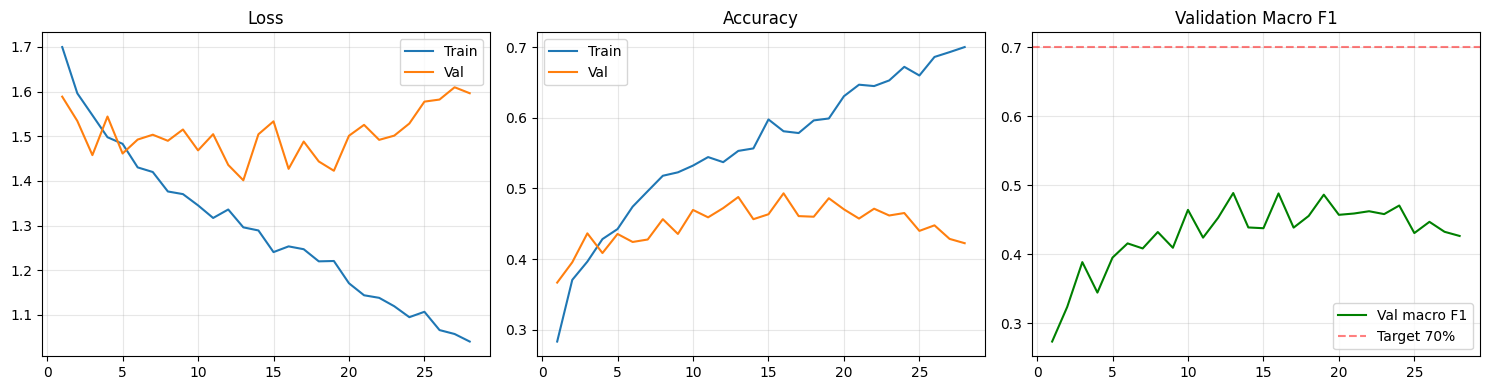

Best val F1: 0.4885


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
ep = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], label='Train')
axes[0].plot(ep, history['val_loss'],   label='Val')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, history['train_acc'], label='Train')
axes[1].plot(ep, history['val_acc'],   label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)

axes[2].plot(ep, history['val_f1'], color='green', label='Val macro F1')
axes[2].axhline(y=0.7, color='red', linestyle='--', alpha=0.5, label='Target 70%')
axes[2].set_title('Validation Macro F1'); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_curves.png', dpi=120)
plt.show()
print(f'Best val F1: {max(history["val_f1"]):.4f}')

## Cell 8 — Final test set evaluation

In [8]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
print(f'Loaded: epoch={ckpt["epoch"]+1}  val_acc={ckpt["val_acc"]:.4f}  val_f1={ckpt["val_f1_macro"]:.4f}')

test_loss, test_acc, test_f1_macro, test_f1_w, test_preds, test_labels_arr, test_probs = \
    evaluate(model, test_loader, criterion)

test_prec  = precision_score(test_labels_arr, test_preds, average='weighted', zero_division=0)
test_rec   = recall_score(test_labels_arr,    test_preds, average='weighted', zero_division=0)
test_kappa = cohen_kappa_score(test_labels_arr, test_preds)
test_mcc   = matthews_corrcoef(test_labels_arr, test_preds)
try:
    test_auc = roc_auc_score(
        label_binarize(test_labels_arr, classes=list(range(6))),
        test_probs, multi_class='ovr'
    )
except:
    test_auc = 0.0

print()
print('=' * 60)
print('        FINAL TEST SET RESULTS')
print('=' * 60)
print(f'  Accuracy     : {test_acc:.4f}')
print(f'  Macro F1     : {test_f1_macro:.4f}  ← primary metric')
print(f'  Weighted F1  : {test_f1_w:.4f}')
print(f'  Precision    : {test_prec:.4f}  (weighted)')
print(f'  Recall       : {test_rec:.4f}  (weighted)')
print(f'  ROC AUC      : {test_auc:.4f}  (OvR macro)')
print(f'  Cohen Kappa  : {test_kappa:.4f}')
print(f'  MCC          : {test_mcc:.4f}')
print('=' * 60)
print()
print(classification_report(
    test_labels_arr, test_preds,
    target_names=[EMOTION_NAMES[i] for i in range(6)]
))

Loaded: epoch=13  val_acc=0.4878  val_f1=0.4885

        FINAL TEST SET RESULTS
  Accuracy     : 0.4551
  Macro F1     : 0.4568  ← primary metric
  Weighted F1  : 0.4573
  Precision    : 0.5044  (weighted)
  Recall       : 0.4551  (weighted)
  ROC AUC      : 0.8208  (OvR macro)
  Cohen Kappa  : 0.3451
  MCC          : 0.3517

              precision    recall  f1-score   support

         ANG       0.90      0.48      0.63       196
         DIS       0.32      0.39      0.35       196
         FEA       0.45      0.33      0.38       196
         SAD       0.40      0.73      0.52       196
         NEU       0.49      0.40      0.44       167
         HAP       0.46      0.39      0.43       196

    accuracy                           0.46      1147
   macro avg       0.50      0.45      0.46      1147
weighted avg       0.50      0.46      0.46      1147



## Cell 9 — Confusion Matrix

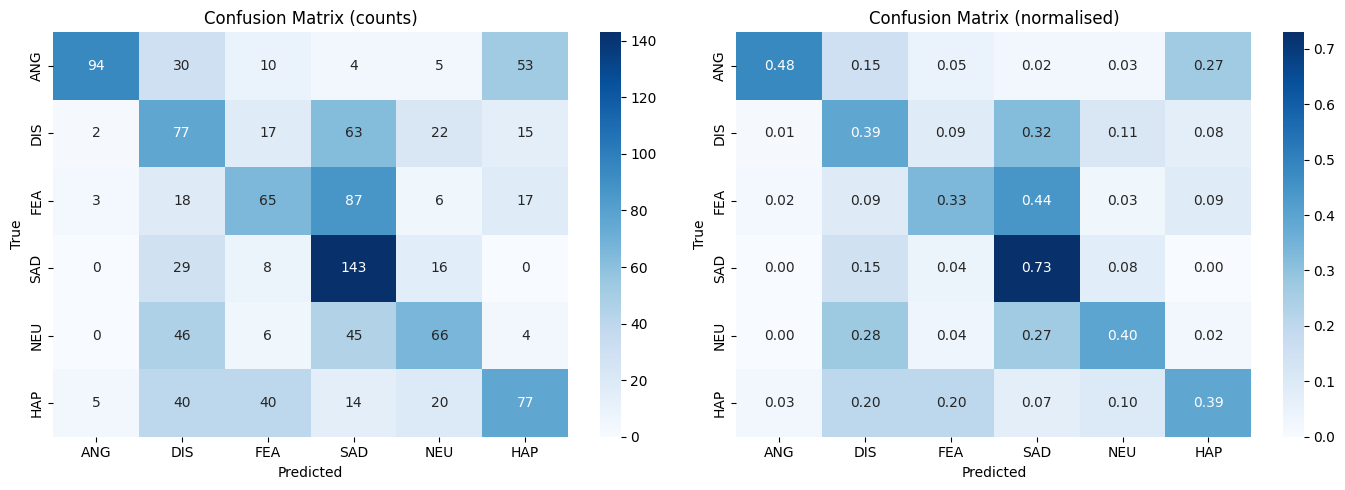

Saved: confusion_matrix.png


In [9]:
emo_names = [EMOTION_NAMES[i] for i in range(6)]
cm        = confusion_matrix(test_labels_arr, test_preds)
cm_norm   = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm,      annot=True, fmt='d',   cmap='Blues',
            xticklabels=emo_names, yticklabels=emo_names, ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)');     axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=emo_names, yticklabels=emo_names, ax=axes[1])
axes[1].set_title('Confusion Matrix (normalised)'); axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

## Cell 10 — ROC Curves

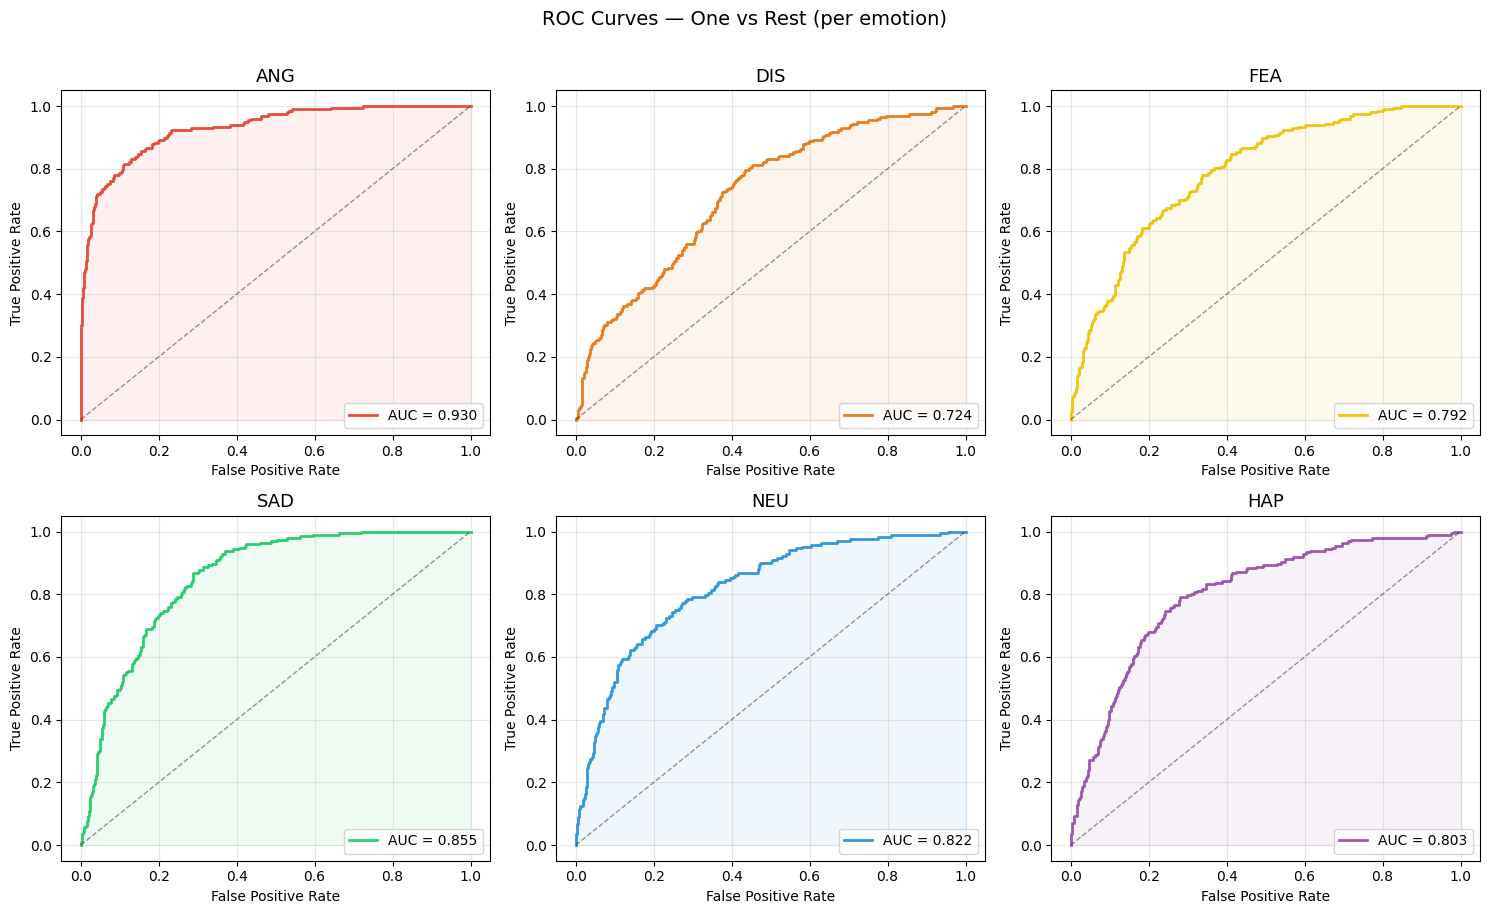

AUC per emotion:
  ANG : 0.9297
  DIS : 0.7236
  FEA : 0.7916
  SAD : 0.8547
  NEU : 0.8217
  HAP : 0.8033
  Mean  : 0.8208


In [10]:
labels_bin = label_binarize(test_labels_arr, classes=list(range(6)))
colors     = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db','#9b59b6']

fig, axes  = plt.subplots(2, 3, figsize=(15, 9))
auc_scores = {}

for i, ax in enumerate(axes.flatten()):
    fpr, tpr, _ = roc_curve(labels_bin[:, i], test_probs[:, i])
    roc_auc      = auc(fpr, tpr)
    auc_scores[EMOTION_NAMES[i]] = roc_auc
    ax.plot(fpr, tpr, color=colors[i], lw=2, label=f'AUC = {roc_auc:.3f}')
    ax.plot([0,1],[0,1],'k--',lw=1,alpha=0.4)
    ax.fill_between(fpr, tpr, alpha=0.08, color=colors[i])
    ax.set_title(EMOTION_NAMES[i], fontsize=13)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.legend(loc='lower right')
    ax.grid(alpha=0.3)

plt.suptitle('ROC Curves — One vs Rest (per emotion)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('AUC per emotion:')
for name, score in auc_scores.items():
    print(f'  {name} : {score:.4f}')
print(f'  Mean  : {np.mean(list(auc_scores.values())):.4f}')

## Cell 11 — Sentiment-level results (3 classes)

Sentiment-level (3-class) results:
  Accuracy : 0.6914
  Macro F1 : 0.5533

              precision    recall  f1-score   support

    Negative       0.77      0.83      0.80       784
     Neutral       0.49      0.40      0.44       167
    Positive       0.46      0.39      0.43       196

    accuracy                           0.69      1147
   macro avg       0.57      0.54      0.55      1147
weighted avg       0.68      0.69      0.68      1147



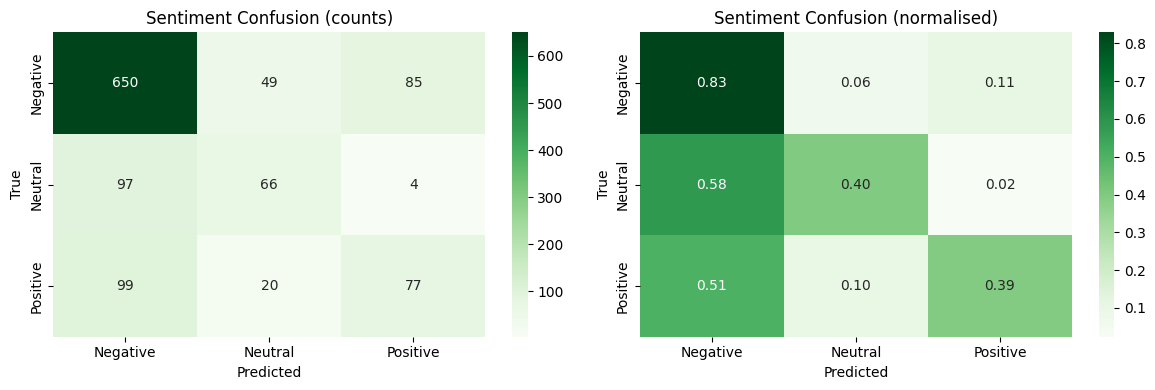

Saved: sentiment_confusion.png


In [11]:
sent_preds  = np.array([EMOTION_TO_SENT[p] for p in test_preds])
sent_labels = np.array([EMOTION_TO_SENT[l] for l in test_labels_arr])
sent_acc    = accuracy_score(sent_labels, sent_preds)
sent_f1     = f1_score(sent_labels, sent_preds, average='macro', zero_division=0)

print('Sentiment-level (3-class) results:')
print(f'  Accuracy : {sent_acc:.4f}')
print(f'  Macro F1 : {sent_f1:.4f}')
print()
print(classification_report(
    sent_labels, sent_preds,
    target_names=['Negative', 'Neutral', 'Positive']
))

sent_cm   = confusion_matrix(sent_labels, sent_preds)
sent_norm = sent_cm.astype(float) / sent_cm.sum(axis=1, keepdims=True)
sent_names = ['Negative', 'Neutral', 'Positive']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.heatmap(sent_cm,   annot=True, fmt='d',   cmap='Greens',
            xticklabels=sent_names, yticklabels=sent_names, ax=axes[0])
axes[0].set_title('Sentiment Confusion (counts)'); axes[0].set_ylabel('True'); axes[0].set_xlabel('Predicted')
sns.heatmap(sent_norm, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=sent_names, yticklabels=sent_names, ax=axes[1])
axes[1].set_title('Sentiment Confusion (normalised)'); axes[1].set_ylabel('True'); axes[1].set_xlabel('Predicted')
plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/sentiment_confusion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sentiment_confusion.png')

## Cell 12 — Save results summary

In [12]:
summary = f"""MSA Results — CREMA-D (wav2vec2 + ResNet50)
==========================================
Dataset      : CREMA-D (7442 clips, 91 actors)
Modalities   : Audio (wav2vec2 768-d) + Video (ResNet50 512-d)
Architecture : TwoModalCoAttention x2 + Gating + Transformer
Split        : Actor-based 70/15/15

6-CLASS EMOTION RESULTS
  Accuracy     : {test_acc:.4f}
  Macro F1     : {test_f1_macro:.4f}
  Weighted F1  : {test_f1_w:.4f}
  Precision    : {test_prec:.4f}
  Recall       : {test_rec:.4f}
  ROC AUC      : {test_auc:.4f}
  Cohen Kappa  : {test_kappa:.4f}
  MCC          : {test_mcc:.4f}

3-CLASS SENTIMENT RESULTS
  Accuracy     : {sent_acc:.4f}
  Macro F1     : {sent_f1:.4f}

AUC per emotion:
""" + '\n'.join(f'  {k} : {v:.4f}' for k, v in auc_scores.items())

with open(f'{SAVE_DIR}/results_summary.txt', 'w') as f:
    f.write(summary)

ckpt = torch.load(CKPT_PATH, map_location='cpu')
print('Checkpoint info:')
print(f'  Epoch        : {ckpt["epoch"]+1}')
print(f'  Val accuracy : {ckpt["val_acc"]:.4f}')
print(f'  Val F1 macro : {ckpt["val_f1_macro"]:.4f}')
print(f'  File size    : {os.path.getsize(CKPT_PATH)/1e6:.1f} MB')
print(f'  Location     : {CKPT_PATH}')
print()
print(summary)
print('\nFiles saved in Drive/crema_msa_v2/:')
for f in sorted(os.listdir(SAVE_DIR)):
    size = os.path.getsize(f'{SAVE_DIR}/{f}') / 1e6
    print(f'  {f:40s} {size:.1f} MB')

Checkpoint info:
  Epoch        : 13
  Val accuracy : 0.4878
  Val F1 macro : 0.4885
  File size    : 40.0 MB
  Location     : /content/drive/MyDrive/crema_msa_v2/best_model.pth

MSA Results — CREMA-D (wav2vec2 + ResNet50)
Dataset      : CREMA-D (7442 clips, 91 actors)
Modalities   : Audio (wav2vec2 768-d) + Video (ResNet50 512-d)
Architecture : TwoModalCoAttention x2 + Gating + Transformer
Split        : Actor-based 70/15/15

6-CLASS EMOTION RESULTS
  Accuracy     : 0.4551
  Macro F1     : 0.4568
  Weighted F1  : 0.4573
  Precision    : 0.5044
  Recall       : 0.4551
  ROC AUC      : 0.8208
  Cohen Kappa  : 0.3451
  MCC          : 0.3517

3-CLASS SENTIMENT RESULTS
  Accuracy     : 0.6914
  Macro F1     : 0.5533

AUC per emotion:
  ANG : 0.9297
  DIS : 0.7236
  FEA : 0.7916
  SAD : 0.8547
  NEU : 0.8217
  HAP : 0.8033

Files saved in Drive/crema_msa_v2/:
  best_model.pth                           40.0 MB
  confusion_matrix.png                     0.1 MB
  feature_check.png             

---
## Done — what to do next

1. Download `best_model.pth` from Drive
2. Check the results — if macro F1 > 0.55 (55%) on 6 classes, sentiment accuracy will be 70%+
3. Reply with your results and we build the Flask web app

**Files for your thesis:**
- `training_curves.png` — shows model learning over time
- `confusion_matrix.png` — 6-class emotion confusion matrix
- `roc_curves.png` — ROC curve per emotion with AUC
- `sentiment_confusion.png` — 3-class sentiment matrix
- `results_summary.txt` — all metrics in one place